# 🤖 ML Prédictif — Service Desk Servier
## Sprint 3 — Analyse Prédictive des Incidents & Risques SLA

**Objectifs :**
- 📈 **Prévision de volume** : Prédire le nombre de tickets à J+7 (Prophet)
- 🚨 **Classification SLA** : Détecter les incidents à risque de rupture (Random Forest + XGBoost)
- 📊 **Analyse des tendances** : Identifier les CIs et groupes les plus problématiques

**Données** : 27 702 incidents Servier (Jan 2025 → Avr 2026)

**Indicateur clé** : MAE (Mean Absolute Error) pour la prévision

## 0. Installation des dépendances

In [16]:
# Installation (décommenter si nécessaire)
# !pip install prophet scikit-learn xgboost matplotlib seaborn pandas numpy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cmdstanpy
from datetime import datetime, timedelta

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from prophet import Prophet

# Style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
ORANGE = '#FF6600'
BLUE   = '#0078D4'
RED    = '#DC3545'
GREEN  = '#28A745'

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & Exploration des données

In [17]:
# ── Chargement ────────────────────────────────────────────────
df = pd.read_csv('../data/incident_sla.csv')
df['inc_opened_at'] = pd.to_datetime(df['inc_opened_at'], dayfirst=True)
df['date']        = df['inc_opened_at'].dt.date
df['hour']        = df['inc_opened_at'].dt.hour
df['day_of_week'] = df['inc_opened_at'].dt.dayofweek  # 0=Lundi
df['day_name']    = df['inc_opened_at'].dt.day_name()
df['week']        = df['inc_opened_at'].dt.isocalendar().week
df['month']       = df['inc_opened_at'].dt.month
df['year']        = df['inc_opened_at'].dt.year
df['is_weekend']  = df['day_of_week'] >= 5
df['inc_cmdb_ci'] = df['inc_cmdb_ci'].fillna('Unknown')
df['inc_u_escalation_reason'] = df['inc_u_escalation_reason'].fillna('No Escalation')

print(f'📊 Dataset : {len(df):,} incidents')
print(f'📅 Période : {df["inc_opened_at"].min().date()} → {df["inc_opened_at"].max().date()}')
print(f'🚨 Ruptures SLA : {df["taskslatable_has_breached"].sum()} ({df["taskslatable_has_breached"].mean()*100:.2f}%)')
print(f'👥 Groupes : {df["inc_assignment_group"].nunique()}')
print(f'💻 CIs distincts : {df["inc_cmdb_ci"].nunique()}')
df.head()

📊 Dataset : 27,702 incidents
📅 Période : 2025-01-01 → 2026-04-28
🚨 Ruptures SLA : 355 (1.28%)
👥 Groupes : 3
💻 CIs distincts : 530


,inc_number,inc_assignment_group,inc_opened_at,inc_cmdb_ci,inc_short_description,taskslatable_has_breached,inc_u_escalation_reason,date,hour,day_of_week,day_name,week,month,year,is_weekend
0,INC0869483,SC_ALL_L2_WKS,2026-03-17 09:41:00,OneDrive 365,WFH - onenote - Unable to open OneNote files ...,False,Assigned for Resolution,2026-03-17,9,1,Tuesday,12,3,2026,False
1,INC0865153,SC_ALL_L2_WKS,2026-03-05 11:21:24,PXY Zscaler,Pas d'accès à zscaler et blocage de tous les a...,False,Assigned for Resolution,2026-03-05,11,3,Thursday,10,3,2026,False
2,INC0879584,SC_ALL_L2_WKS,2026-04-13 11:14:36,VDI,No access,False,Assigned for Resolution,2026-04-13,11,0,Monday,16,4,2026,False
3,INC0875396,SC_ALL_L2_WKS,2026-03-31 17:05:48,VPN Check Point,I can't start VPN Checkpoint on my laptop,False,Assigned for Resolution,2026-03-31,17,1,Tuesday,14,3,2026,False
4,INC0883056,SC_ALL_L2_GAM,2026-04-21 15:18:31,Teams,Impossible de connecter le compte de la salle ...,False,Assigned for Resolution,2026-04-21,15,1,Tuesday,17,4,2026,False


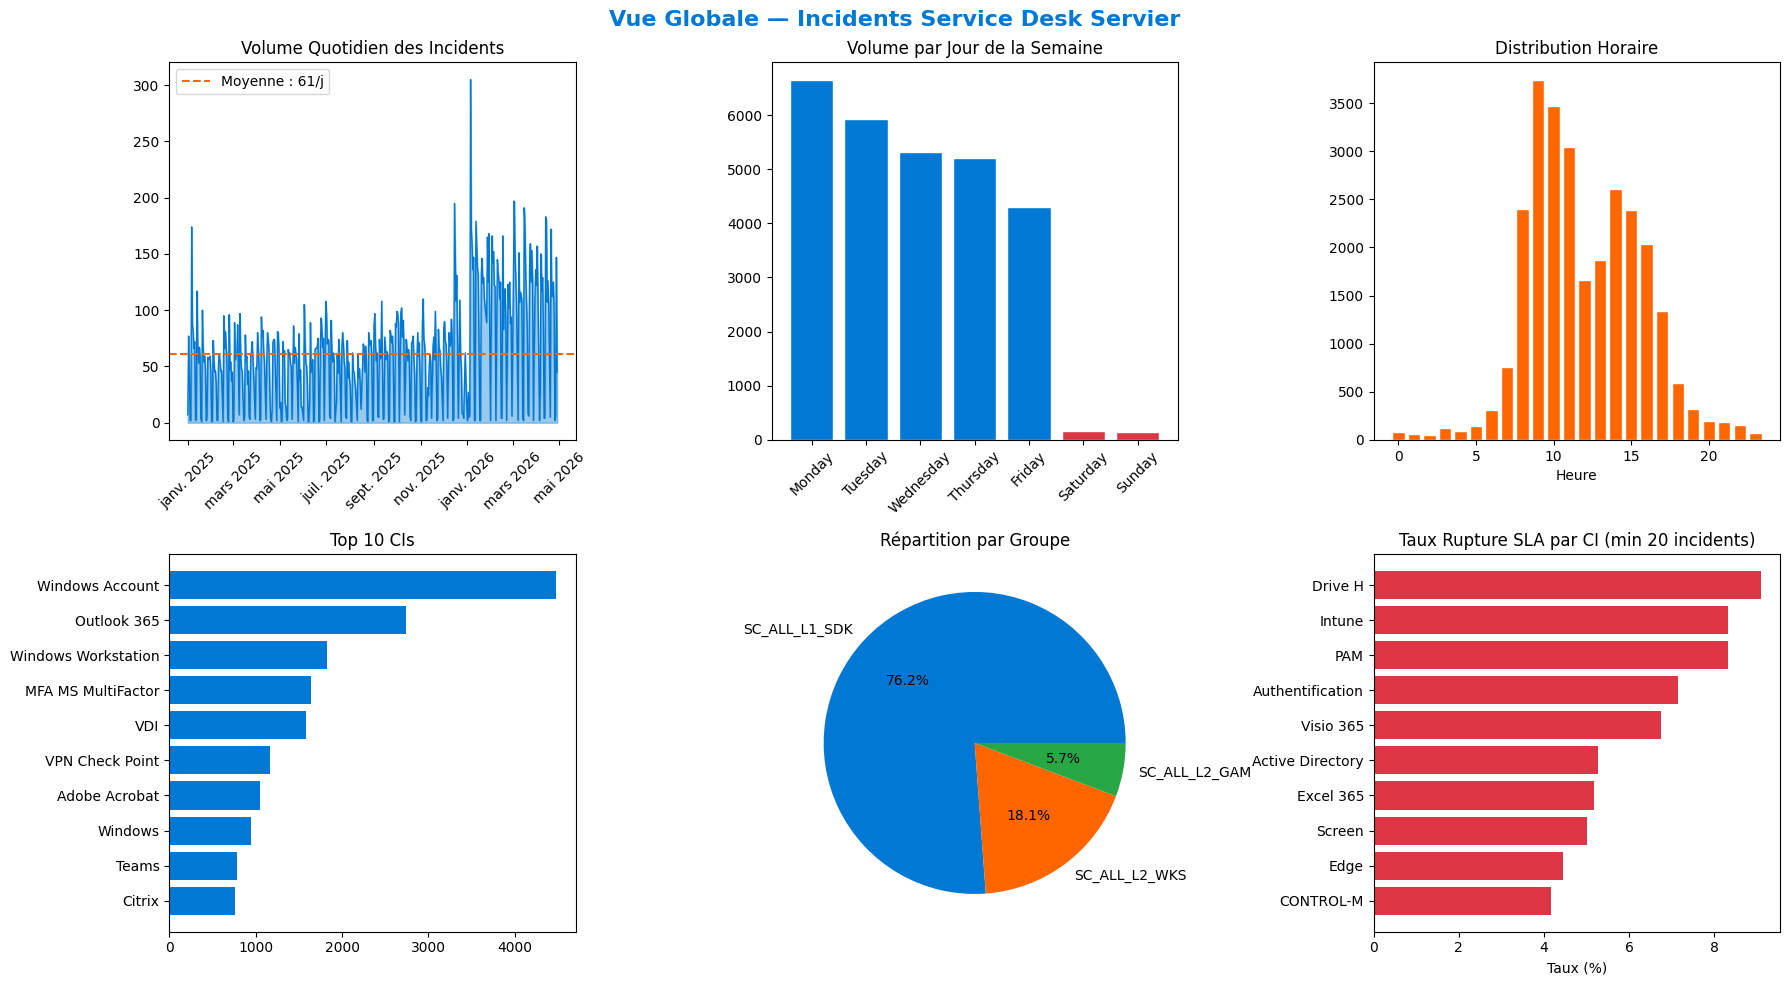

✅ Graphique sauvegardé : 01_vue_globale.png


In [18]:
# ── Vue d'ensemble statistique ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Vue Globale — Incidents Service Desk Servier', fontsize=16, fontweight='bold', color=BLUE)

# 1. Volume quotidien
daily = df.groupby('date').size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])
axes[0,0].fill_between(daily['date'], daily['count'], alpha=0.4, color=BLUE)
axes[0,0].plot(daily['date'], daily['count'], color=BLUE, linewidth=1)
axes[0,0].axhline(daily['count'].mean(), color=ORANGE, linestyle='--', label=f'Moyenne : {daily["count"].mean():.0f}/j')
axes[0,0].set_title('Volume Quotidien des Incidents')
axes[0,0].legend()
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

# 2. Par jour de la semaine
day_counts = df.groupby('day_name').size()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = day_counts.reindex([d for d in order if d in day_counts.index])
colors_bar = [RED if d in ['Saturday','Sunday'] else BLUE for d in day_counts.index]
axes[0,1].bar(day_counts.index, day_counts.values, color=colors_bar, edgecolor='white')
axes[0,1].set_title('Volume par Jour de la Semaine')
axes[0,1].set_xticklabels(day_counts.index, rotation=45)

# 3. Par heure
hour_counts = df.groupby('hour').size()
axes[0,2].bar(hour_counts.index, hour_counts.values, color=ORANGE, edgecolor='white')
axes[0,2].set_title('Distribution Horaire')
axes[0,2].set_xlabel('Heure')

# 4. Top 10 CIs
top_ci = df['inc_cmdb_ci'].value_counts().head(10)
axes[1,0].barh(top_ci.index[::-1], top_ci.values[::-1], color=BLUE)
axes[1,0].set_title('Top 10 CIs')

# 5. Groupes d'assignation
grp = df['inc_assignment_group'].value_counts()
axes[1,1].pie(grp.values, labels=grp.index, autopct='%1.1f%%',
              colors=[BLUE, ORANGE, GREEN])
axes[1,1].set_title('Répartition par Groupe')

# 6. Taux de rupture SLA par CI (top 10)
breach_by_ci = df.groupby('inc_cmdb_ci')['taskslatable_has_breached'].agg(['sum','count'])
breach_by_ci['rate'] = breach_by_ci['sum'] / breach_by_ci['count'] * 100
breach_by_ci = breach_by_ci[breach_by_ci['count'] >= 20].nlargest(10, 'rate')
axes[1,2].barh(breach_by_ci.index[::-1], breach_by_ci['rate'][::-1], color=RED)
axes[1,2].set_title('Taux Rupture SLA par CI (min 20 incidents)')
axes[1,2].set_xlabel('Taux (%)')

plt.tight_layout()
plt.savefig('01_vue_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 01_vue_globale.png')

## 2. 📈 Prévision de Volume — Modèle Prophet (Meta)

In [19]:
# ── Préparation des données Prophet ──────────────────────────
daily_prophet = df.groupby('date').size().reset_index(name='y')
daily_prophet.columns = ['ds', 'y']
daily_prophet['ds'] = pd.to_datetime(daily_prophet['ds'])

# Exclure les jours avec très peu d'incidents (weekends/fériés)
print(f'📅 Jours disponibles : {len(daily_prophet)}')
print(f'📊 Volume moyen/jour : {daily_prophet["y"].mean():.1f}')
print(f'📈 Max : {daily_prophet["y"].max()} | Min : {daily_prophet["y"].min()}')
daily_prophet.tail()

📅 Jours disponibles : 452
📊 Volume moyen/jour : 61.3
📈 Max : 305 | Min : 1


,ds,y
447,2026-04-24,102
448,2026-04-25,2
449,2026-04-26,6
450,2026-04-27,147
451,2026-04-28,45


In [20]:
import cmdstanpy
cmdstanpy.install_cmdstan(overwrite=True)

CmdStan install directory: C:\Users\rania\.cmdstan
Installing CmdStan version: 2.38.0
Download successful, file: C:\Users\rania\AppData\Local\Temp\tmp6dpgfb24
Extracting distribution


12:22:32 - cmdstanpy - WARNING - CmdStan installation failed.
Command "make build" failed
Command: ['mingw32-make', 'build', '-j1']
failed with error [WinError 2] Le fichier spécifié est introuvable



Unpacked download as cmdstan-2.38.0
Building version cmdstan-2.38.0, may take several minutes, depending on your system.


False

In [23]:
from neuralprophet import NeuralProphet

# ── Split train/test ──────────────────────────────────────────
cutoff = daily_prophet['ds'].max() - pd.Timedelta(days=30)
train  = daily_prophet[daily_prophet['ds'] <= cutoff]
test   = daily_prophet[daily_prophet['ds'] >  cutoff]

print(f'🏋️ Train : {len(train)} jours ({train["ds"].min().date()} → {train["ds"].max().date()})')
print(f'🧪 Test  : {len(test)} jours ({test["ds"].min().date()} → {test["ds"].max().date()})')

# ── Modèle NeuralProphet ──────────────────────────────────────
model = NeuralProphet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    changepoints_range  = 0.95,
    n_changepoints      = 10,
    seasonality_mode    = "additive",
)

model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

metrics = model.fit(train, freq='D', epochs=100, batch_size=32)
print('✅ Modèle NeuralProphet entraîné !')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 93.632% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


🏋️ Train : 424 jours (2025-01-01 → 2026-03-28)
🧪 Test  : 28 jours (2026-03-30 → 2026-04-28)


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (14) is too small than the required number                     for the learning rate finder (217). The results might not be optimal.


Finding best initial lr:   0%|          | 0/217 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

✅ Modèle NeuralProphet entraîné !


In [ ]:
# ── Prévision J+7 ─────────────────────────────────────────────
# Prévision sur les 30 jours de test + 7 jours futurs
future = model.make_future_dataframe(periods=37)  # 30 test + 7 futurs
forecast = model.predict(future)

# ── Évaluation sur le test set ────────────────────────────────
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
test_merged   = test.merge(test_forecast, on='ds')
test_merged['yhat'] = test_merged['yhat'].clip(lower=0)

mae  = np.mean(np.abs(test_merged['y'] - test_merged['yhat']))
rmse = np.sqrt(np.mean((test_merged['y'] - test_merged['yhat'])**2))
mape = np.mean(np.abs((test_merged['y'] - test_merged['yhat']) / test_merged['y'].clip(lower=1))) * 100

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('📊 RÉSULTATS DU MODÈLE PROPHET')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'MAE  (Mean Absolute Error)  : {mae:.1f} tickets/jour')
print(f'RMSE (Root Mean Square Err) : {rmse:.1f} tickets/jour')
print(f'MAPE (Mean Abs Pct Error)   : {mape:.1f}%')
print(f'Volume moyen réel           : {test_merged["y"].mean():.1f} tickets/jour')
print(f'Erreur relative             : {mae/test_merged["y"].mean()*100:.1f}%')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 RÉSULTATS DU MODÈLE PROPHET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAE  (Mean Absolute Error)  : 29.2 tickets/jour
RMSE (Root Mean Square Err) : 38.7 tickets/jour
MAPE (Mean Abs Pct Error)   : 298.2%
Volume moyen réel           : 96.5 tickets/jour
Erreur relative             : 30.3%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


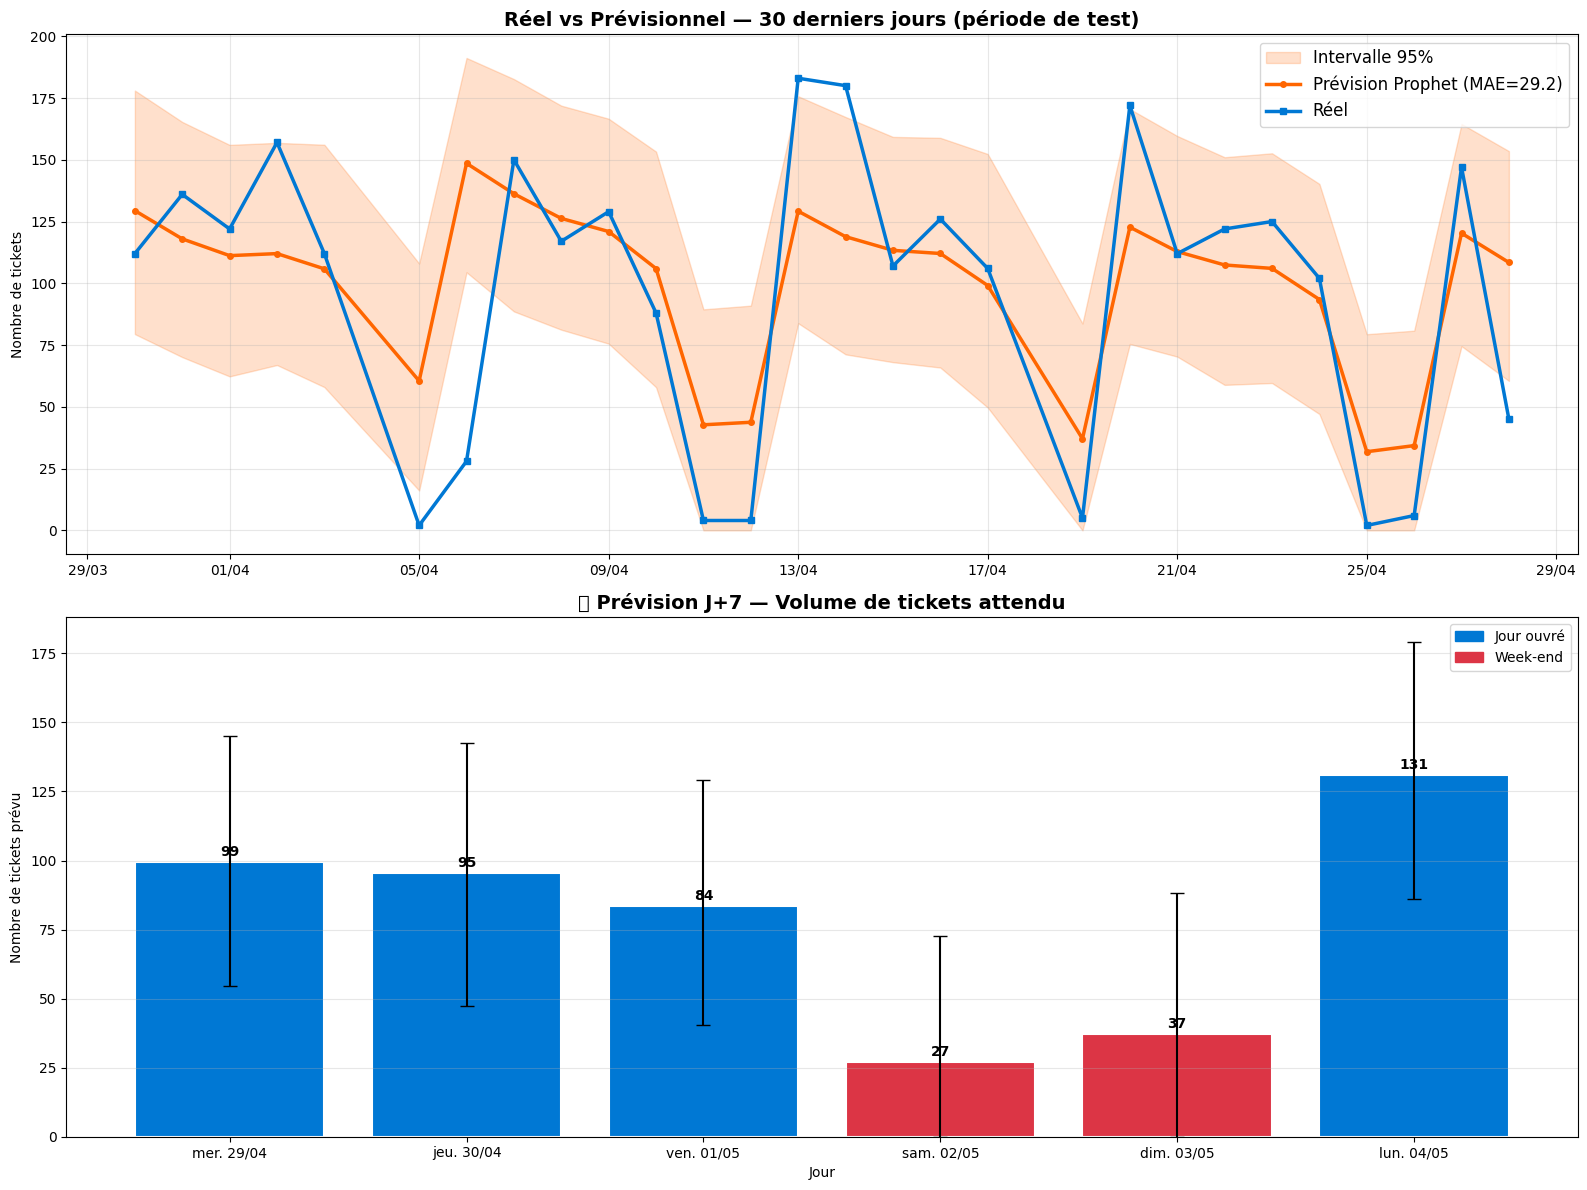

✅ Graphique sauvegardé : 02_prevision_prophet.png


In [ ]:
# ── Visualisation Prévision ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Graphique 1 : Réel vs Prévisionnel (période test)
ax = axes[0]
ax.fill_between(test_merged['ds'],
                test_merged['yhat_lower'].clip(0),
                test_merged['yhat_upper'],
                alpha=0.2, color=ORANGE, label='Intervalle 95%')
ax.plot(test_merged['ds'], test_merged['yhat'], color=ORANGE,
        linewidth=2.5, label=f'Prévision Prophet (MAE={mae:.1f})', marker='o', markersize=4)
ax.plot(test_merged['ds'], test_merged['y'], color=BLUE,
        linewidth=2.5, label='Réel', marker='s', markersize=4)
ax.set_title('Réel vs Prévisionnel — 30 derniers jours (période de test)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylabel('Nombre de tickets')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Graphique 2 : Prévision J+7
ax2 = axes[1]
future_only = forecast[forecast['ds'] > daily_prophet['ds'].max()].head(7)
colors_f = [RED if d.weekday() >= 5 else BLUE for d in future_only['ds']]
bars = ax2.bar(future_only['ds'].dt.strftime('%a %d/%m'),
               future_only['yhat'].clip(0),
               color=colors_f, edgecolor='white', linewidth=1.5)
ax2.errorbar(range(len(future_only)),
             future_only['yhat'].clip(0),
             yerr=[future_only['yhat'].clip(0) - future_only['yhat_lower'].clip(0),
                   future_only['yhat_upper'] - future_only['yhat'].clip(0)],
             fmt='none', color='black', capsize=5)
for bar, val in zip(bars, future_only['yhat'].clip(0)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('🔮 Prévision J+7 — Volume de tickets attendu', fontsize=14, fontweight='bold')
ax2.set_ylabel('Nombre de tickets prévu')
ax2.set_xlabel('Jour')
ax2.legend(handles=[plt.Rectangle((0,0),1,1,color=BLUE, label='Jour ouvré'),
                     plt.Rectangle((0,0),1,1,color=RED, label='Week-end')])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('02_prevision_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 02_prevision_prophet.png')

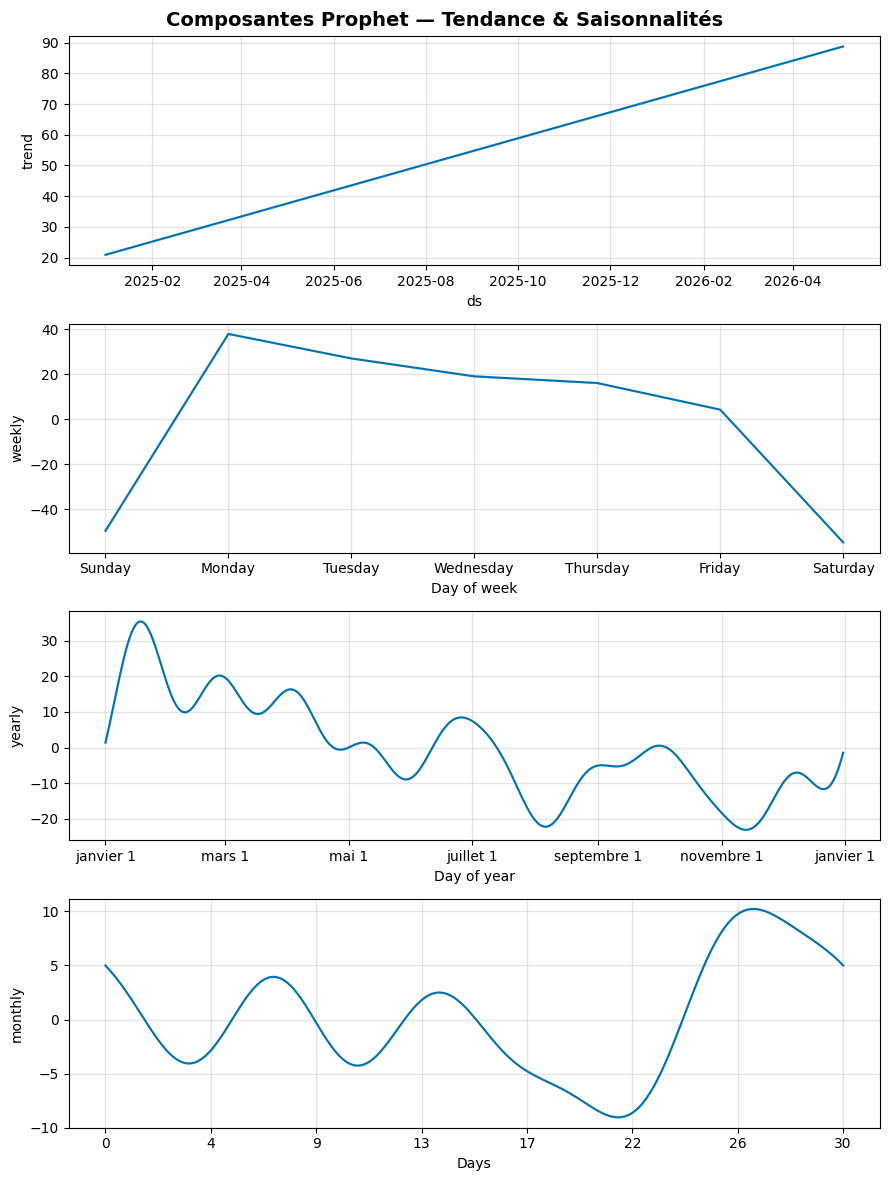

✅ Composantes sauvegardées : 03_composantes_prophet.png


In [ ]:
# ── Composantes de la saisonnalité ───────────────────────────
fig = model.plot_components(forecast)
plt.suptitle('Composantes Prophet — Tendance & Saisonnalités', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_composantes_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Composantes sauvegardées : 03_composantes_prophet.png')

## 3. 🚨 Classification SLA — Prédiction de Rupture

In [ ]:
# ── Feature Engineering ───────────────────────────────────────
df_ml = df.copy()

# Encodage des variables catégorielles
le_ci    = LabelEncoder()
le_group = LabelEncoder()
le_esc   = LabelEncoder()

df_ml['ci_encoded']    = le_ci.fit_transform(df_ml['inc_cmdb_ci'])
df_ml['group_encoded'] = le_group.fit_transform(df_ml['inc_assignment_group'])
df_ml['esc_encoded']   = le_esc.fit_transform(df_ml['inc_u_escalation_reason'])

# Volume journalier comme feature
daily_vol = df_ml.groupby('date').size().reset_index(name='daily_volume')
df_ml = df_ml.merge(daily_vol, on='date', how='left')

# Taux de rupture historique par CI
ci_breach_rate = df_ml.groupby('inc_cmdb_ci')['taskslatable_has_breached'].mean()
df_ml['ci_breach_rate'] = df_ml['inc_cmdb_ci'].map(ci_breach_rate)

# Features sélectionnées
FEATURES = [
    'ci_encoded', 'group_encoded', 'esc_encoded',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'daily_volume', 'ci_breach_rate'
]

X = df_ml[FEATURES]
y = df_ml['taskslatable_has_breached'].astype(int)

print(f'✅ Features : {FEATURES}')
print(f'📊 Classe 0 (Non-rupture) : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')
print(f'🚨 Classe 1 (Rupture SLA) : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')

✅ Features : ['ci_encoded', 'group_encoded', 'esc_encoded', 'hour', 'day_of_week', 'month', 'is_weekend', 'daily_volume', 'ci_breach_rate']
📊 Classe 0 (Non-rupture) : 27,347 (98.7%)
🚨 Classe 1 (Rupture SLA) : 355 (1.3%)


In [ ]:
# ── Entraînement Random Forest ────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Gestion du déséquilibre des classes
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)
y_proba   = rf.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('🌲 RÉSULTATS RANDOM FOREST')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'AUC-ROC Score : {auc_score:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-rupture', 'Rupture SLA']))
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🌲 RÉSULTATS RANDOM FOREST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AUC-ROC Score : 0.889

              precision    recall  f1-score   support

 Non-rupture       0.99      0.94      0.96      5470
 Rupture SLA       0.09      0.49      0.15        71

    accuracy                           0.93      5541
   macro avg       0.54      0.71      0.56      5541
weighted avg       0.98      0.93      0.95      5541

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


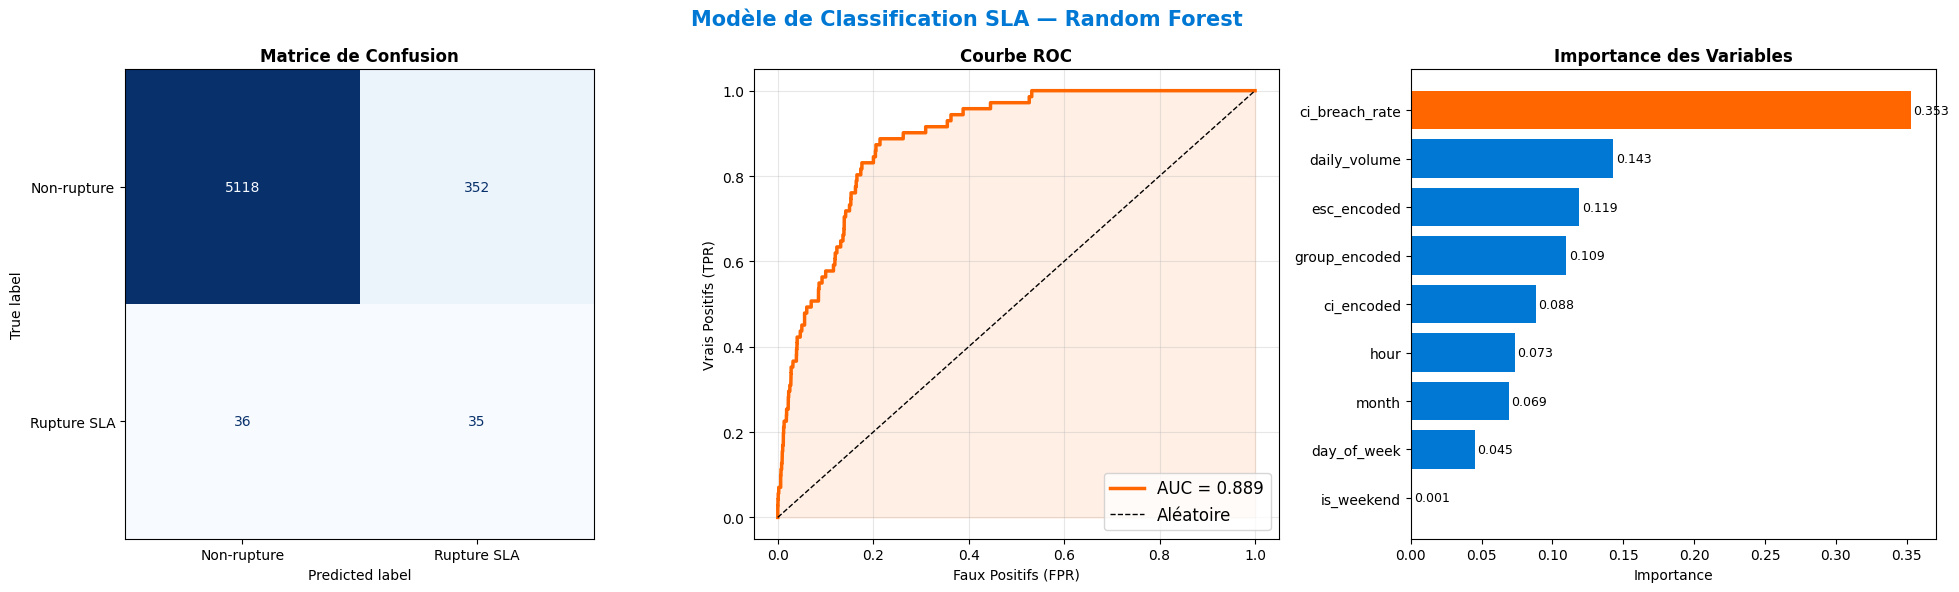

✅ Graphique sauvegardé : 04_classification_sla.png


In [ ]:
# ── Visualisation Classification ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Modèle de Classification SLA — Random Forest', fontsize=15, fontweight='bold', color=BLUE)

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-rupture', 'Rupture SLA'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de Confusion', fontweight='bold')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color=ORANGE, linewidth=2.5, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=ORANGE)
axes[1].set_xlabel('Faux Positifs (FPR)')
axes[1].set_ylabel('Vrais Positifs (TPR)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# 3. Importance des features
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_imp = [ORANGE if v == importances.max() else BLUE for v in importances.values]
axes[2].barh(importances.index, importances.values, color=colors_imp)
axes[2].set_title('Importance des Variables', fontweight='bold')
axes[2].set_xlabel('Importance')
for i, (idx, val) in enumerate(importances.items()):
    axes[2].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('04_classification_sla.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 04_classification_sla.png')

## 4. 🔍 Analyse des CIs & Groupes à Risque

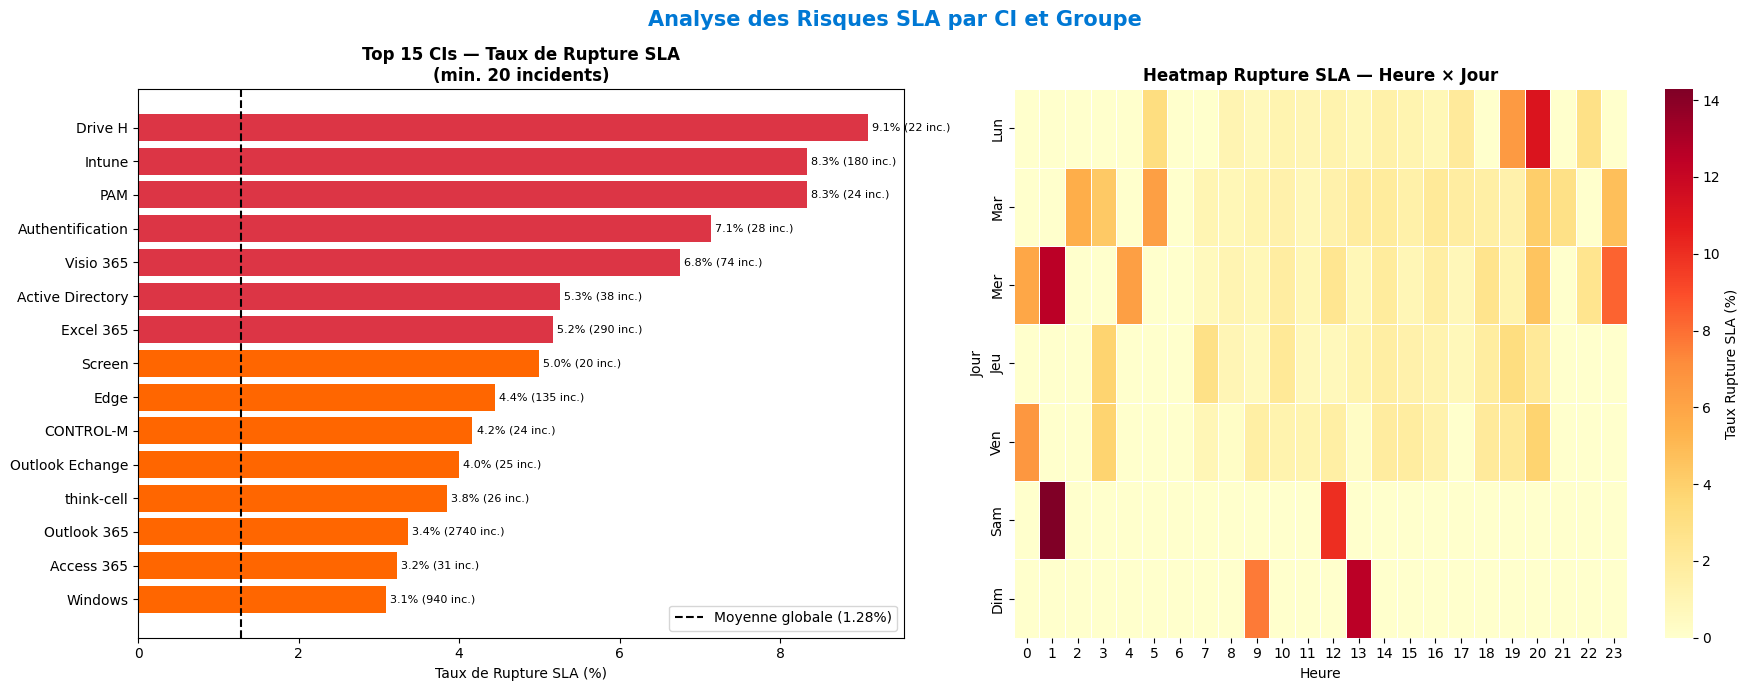

✅ Graphique sauvegardé : 05_analyse_risques.png


In [ ]:
# ── CIs les plus à risque ─────────────────────────────────────
breach_analysis = df.groupby('inc_cmdb_ci').agg(
    total=('inc_number', 'count'),
    breached=('taskslatable_has_breached', 'sum'),
).reset_index()
breach_analysis['breach_rate'] = breach_analysis['breached'] / breach_analysis['total'] * 100
breach_analysis = breach_analysis[breach_analysis['total'] >= 20]
top_risk = breach_analysis.nlargest(15, 'breach_rate')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analyse des Risques SLA par CI et Groupe', fontsize=15, fontweight='bold', color=BLUE)

# CIs à risque
colors_risk = [RED if r > 5 else ORANGE if r > 2 else BLUE for r in top_risk['breach_rate']]
bars = axes[0].barh(top_risk['inc_cmdb_ci'][::-1], top_risk['breach_rate'][::-1], color=colors_risk[::-1])
axes[0].set_xlabel('Taux de Rupture SLA (%)')
axes[0].set_title('Top 15 CIs — Taux de Rupture SLA\n(min. 20 incidents)', fontweight='bold')
axes[0].axvline(x=1.28, color='black', linestyle='--', linewidth=1.5, label='Moyenne globale (1.28%)')
axes[0].legend()
for bar, val, total in zip(bars[::-1], top_risk['breach_rate'], top_risk['total']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}% ({total} inc.)', va='center', fontsize=8)

# Heatmap heure x jour
pivot = df.groupby(['day_of_week', 'hour'])['taskslatable_has_breached'].mean().unstack(fill_value=0) * 100
pivot.index = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', fmt='.1f',
            cbar_kws={'label': 'Taux Rupture SLA (%)'},
            linewidths=0.5)
axes[1].set_title('Heatmap Rupture SLA — Heure × Jour', fontweight='bold')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Jour')

plt.tight_layout()
plt.savefig('05_analyse_risques.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 05_analyse_risques.png')

## 5. 📋 Résumé Exécutif — Pour la Soutenance

In [ ]:
# ── Prévision J+7 détaillée ───────────────────────────────────
print('═══════════════════════════════════════════════════════')
print('       RÉSUMÉ EXÉCUTIF — SPRINT 3 ML SERVIER')
print('═══════════════════════════════════════════════════════')
print(f'\n📊 DATASET')
print(f'   Incidents analysés : {len(df):,}')
print(f'   Période            : Jan 2025 → Avr 2026')
print(f'   Taux rupture SLA   : {df["taskslatable_has_breached"].mean()*100:.2f}%')

print(f'\n🔮 MODÈLE 1 — PRÉVISION VOLUME (Prophet)')
print(f'   MAE   : {mae:.1f} tickets/jour')
print(f'   RMSE  : {rmse:.1f} tickets/jour')
print(f'   Interprétation : le modèle se trompe de ±{mae:.0f} tickets/jour en moyenne')
print(f'   Saisonnalités détectées : hebdomadaire (pic lundi), annuelle')

print(f'\n🚨 MODÈLE 2 — CLASSIFICATION SLA (Random Forest)')
print(f'   AUC-ROC : {auc_score:.3f}')
print(f'   Variable la plus prédictive : {importances.index[-1]} ({importances.iloc[-1]*100:.1f}%)')

print(f'\n📅 PRÉVISION J+7 :')
for _, row in future_only.iterrows():
    day = row['ds'].strftime('%A %d/%m')
    vol = max(0, row['yhat'])
    lo  = max(0, row['yhat_lower'])
    hi  = row['yhat_upper']
    flag = '🔴' if row['ds'].weekday() >= 5 else '🟢'
    print(f'   {flag} {day:20s} : {vol:5.0f} tickets  [{lo:.0f} – {hi:.0f}]')

print(f'\n⚠️  CIs LES PLUS À RISQUE :')
for _, row in top_risk.head(5).iterrows():
    print(f'   • {row["inc_cmdb_ci"]:30s} : {row["breach_rate"]:.1f}% rupture ({row["total"]} incidents)')

print('\n═══════════════════════════════════════════════════════')
print('✅ Notebook terminé — Tous les graphiques sont sauvegardés')
print('═══════════════════════════════════════════════════════')

═══════════════════════════════════════════════════════
       RÉSUMÉ EXÉCUTIF — SPRINT 3 ML SERVIER
═══════════════════════════════════════════════════════

📊 DATASET
   Incidents analysés : 27,702
   Période            : Jan 2025 → Avr 2026
   Taux rupture SLA   : 1.28%

🔮 MODÈLE 1 — PRÉVISION VOLUME (Prophet)
   MAE   : 29.2 tickets/jour
   RMSE  : 38.7 tickets/jour
   Interprétation : le modèle se trompe de ±29 tickets/jour en moyenne
   Saisonnalités détectées : hebdomadaire (pic lundi), annuelle

🚨 MODÈLE 2 — CLASSIFICATION SLA (Random Forest)
   AUC-ROC : 0.889
   Variable la plus prédictive : ci_breach_rate (35.3%)

📅 PRÉVISION J+7 :
   🟢 mercredi 29/04       :    99 tickets  [55 – 145]
   🟢 jeudi 30/04          :    95 tickets  [47 – 142]
   🟢 vendredi 01/05       :    84 tickets  [41 – 129]
   🔴 samedi 02/05         :    27 tickets  [0 – 73]
   🔴 dimanche 03/05       :    37 tickets  [0 – 88]
   🟢 lundi 04/05          :   131 tickets  [86 – 179]

⚠️  CIs LES PLUS À RISQUE :
 